# Tarea 2 — ENO y GRD

IELE756 — Preparación y Análisis de Datos

Integrantes: Gaspar Lammel + Fernando Rodríguez   
Región / comunas asignadas: Las Condes + Curacavi
Fecha: 16/04/2026

## Objetivo

Este notebook construye el panorama de salud de las comunas asignadas utilizando dos datasets complementarios:

- **ENO (Enfermedades de Notificación Obligatoria):** registro nacional de enfermedades de denuncia obligatoria, con datos desde 2007 hasta 2024. Permite analizar tendencias de notificación, distribución por sexo, edad, educación y nacionalidad.
- **GRD (Grupos Relacionados de Diagnóstico):** egresos hospitalarios de establecimientos públicos, codificados con ICD-10. Permite analizar diagnósticos, estadía hospitalaria, severidad y mortalidad intrahospitalaria.

El análisis está organizado en dos grandes bloques:

**Bloque A — ENO:** Carga, limpieza, tendencias, perfil de casos, análisis espacial y tabla resumen.

**Bloque B — GRD:** Carga robusta de archivos 2022-2024, perfil diagnóstico, estadía, severidad, mortalidad y tabla resumen.

> **Nota metodológica:** La categoría `"Desconocido"` en la variable `nacionalidad` del ENO se reporta pero se excluye de los análisis por nacionalidad. Los valores `-99` en GRD se tratan como faltantes.

---
## Bloque A — ENO (Enfermedades de Notificación Obligatoria)

### Parte 0 — Carga y limpieza inicial

#### 0.0 Configuración inicial

Se importan las librerías necesarias y se definen las rutas de trabajo, los códigos de comunas asignadas y el diccionario de nombres.

#### 0.1 Cargar ENO

El dataset ENO está en formato CSV con separador `;` y encoding `utf-8-sig`. Contiene ~333.000 registros a nivel nacional desde 2007 hasta 2024. Se cargan solo las columnas necesarias para el análisis.

#### 0.2 Filtrar a las comunas de interés

Se filtra por `codigo_comuna_residencia` a Las Condes (13114) y Curacaví (13503).

#### 0.3 Reportar anonimización

Algunos registros tienen el valor `"*****"` en lugar del código de comuna. Esto ocurre cuando el MINSAL anonimiza comunas con pocos casos para proteger la privacidad de los pacientes. Se reporta cuántos registros están en esta situación.

#### 0.4 Limpieza de nacionalidad

La variable `nacionalidad` puede contener `"Desconocido"`. Se reporta su frecuencia y se crea una base limpia `eno_nat` excluyendo estos registros para los análisis por nacionalidad.

#### 0.5 Rango temporal

Se verifica el rango de años disponibles en las comunas filtradas.

In [ ]:
# ============================================================
# TAREA 2 - ENO
# HEALTH LANDSCAPE
# COMUNAS: LAS CONDES (13114) Y CURACAVÍ (13503)
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from google.colab import drive

# Abrir Google Drive
drive.mount('/content/drive')

# ------------------------------------------------------------
# RUTAS DE TRABAJO
# ------------------------------------------------------------
RUTA_BASE = "/content/drive/MyDrive/ColabNotebooks/"
RUTA_ENO = os.path.join(RUTA_BASE, "ENO")
RUTA_COMUNAS = os.path.join(RUTA_BASE, "COMUNAS")
RUTA_OUTPUT = os.path.join(RUTA_BASE, "output")

# Comunas asignadas
MY_COMUNAS = [13114, 13503]

# Mapa de nombres para usar después en tablas y gráficos
MAPA_COMUNAS = {
    13114: "Las Condes",
    13503: "Curacaví"
}

print("Configuración cargada correctamente.")

# ============================================================
# PARTE 0: CARGA Y LIMPIEZA INICIAL
# ============================================================

# ------------------------------------------------------------
# 0.1 CARGAR ENO
# ------------------------------------------------------------
# Se cargan solo las columnas necesarias para no traer variables
# que no se usarán en el análisis.

eno_cols = [
    "ENO",
    "anho_notificacion",
    "region",
    "codigo_comuna_residencia",
    "nacionalidad",
    "sexo",
    "grupo_edad",
    "nombre_instruccion",
    "cie_10_diagnostico",
    "diagnostico",
    "pais_contagio"
]

eno = pd.read_csv(
    os.path.join(RUTA_ENO, "20241218_base_eno_final.csv"),
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols
)

# Se fuerza a texto para evitar problemas en el filtrado por comuna.
eno["codigo_comuna_residencia"] = eno["codigo_comuna_residencia"].astype(str)

print("=" * 60)
print("PARTE 0.1: TABLA ENO CARGADA")
print("Shape ENO:", eno.shape)
print("\nInfo ENO:")
eno.info()

# ------------------------------------------------------------
# 0.2 FILTRAR LAS COMUNAS DE INTERÉS
# ------------------------------------------------------------
# Como la columna quedó en formato texto, también convertimos
# las comunas objetivo a string para compararlas correctamente.

my_comunas_str = [str(c) for c in MY_COMUNAS]

eno_com = eno[
    eno["codigo_comuna_residencia"].isin(my_comunas_str)
].copy()

print("\n" + "=" * 60)
print("PARTE 0.2: FILTRADO A COMUNAS")
print(f"Filas en mis comunas: {len(eno_com):,}")

# ------------------------------------------------------------
# 0.3 REPORTAR ANONIMIZACIÓN DE COMUNA
# ------------------------------------------------------------
# Algunas filas pueden venir con la comuna anonimizada como '*****'.
# Esto es importante reportarlo porque esos registros no se pueden
# asignar territorialmente a una comuna específica.

anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
anon_pct = (anon_count / len(eno) * 100) if len(eno) > 0 else np.nan

print("\n" + "=" * 60)
print("PARTE 0.3: ANONIMIZACIÓN")
print(f"Filas anonimizadas con '*****': {anon_count:,}")
print(f"Porcentaje anonimizadas: {anon_pct:.2f}%")

# ------------------------------------------------------------
# 0.4 LIMPIEZA DE NACIONALIDADES
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("PARTE 0.4: NACIONALIDAD")
print("Distribución de nacionalidad en ENO filtrado:")
print(eno_com["nacionalidad"].value_counts(dropna=False))

# Para los análisis por nacionalidad se excluye 'Desconocido',
# porque no permite clasificar realmente al caso.

eno_nat = eno_com[
    eno_com["nacionalidad"] != "Desconocido"
].copy()

drop_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum()
drop_pct = (drop_desconocido / len(eno_com) * 100) if len(eno_com) > 0 else np.nan

print(f"\nFilas eliminadas por 'Desconocido': {drop_desconocido:,}")
print(f"Porcentaje eliminado: {drop_pct:.2f}%")
print(f"Filas restantes para análisis por nacionalidad: {len(eno_nat):,}")

# ------------------------------------------------------------
# 0.5 RANGO DE TIEMPO
# ------------------------------------------------------------
# Antes de analizar tendencias, conviene verificar el rango temporal
# real cubierto por los datos filtrados.

print("\n" + "=" * 60)
print("PARTE 0.5: RANGO TEMPORAL")
print("Año mínimo:", eno_com["anho_notificacion"].min())
print("Año máximo:", eno_com["anho_notificacion"].max())

notificaciones_por_anio = (
    eno_com["anho_notificacion"]
    .value_counts()
    .sort_index()
    .reset_index(name="cantidad")
    .rename(columns={"index": "anho_notificacion"})
)

print("\nNotificaciones por año:")
print(notificaciones_por_anio)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuración cargada correctamente.
PARTE 0.1: TABLA ENO CARGADA
Shape ENO: (333300, 11)

Info ENO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object

**Resultado:** El dataset ENO filtrado contiene los registros de Las Condes y Curacaví entre 2007 y 2024. La base `eno_nat` excluye los casos con nacionalidad desconocida y será usada en los análisis comparativos por nacionalidad.

---
### Parte 1 — Tendencias en el tiempo

#### 1.1 Tendencia total de notificaciones

Se grafica la evolución anual del número de notificaciones ENO en las comunas asignadas. Este gráfico permite identificar tendencias generales, el impacto de eventos como la pandemia COVID-19 (donde muchas enfermedades bajaron por el uso de mascarillas y menor circulación), o brotes específicos de enfermedades.

#### 1.2 Tendencia por nacionalidad

Se desagregan las notificaciones por las 3 nacionalidades más frecuentes para observar si los patrones temporales difieren entre grupos. Se excluyen los registros con nacionalidad `"Desconocido"`.

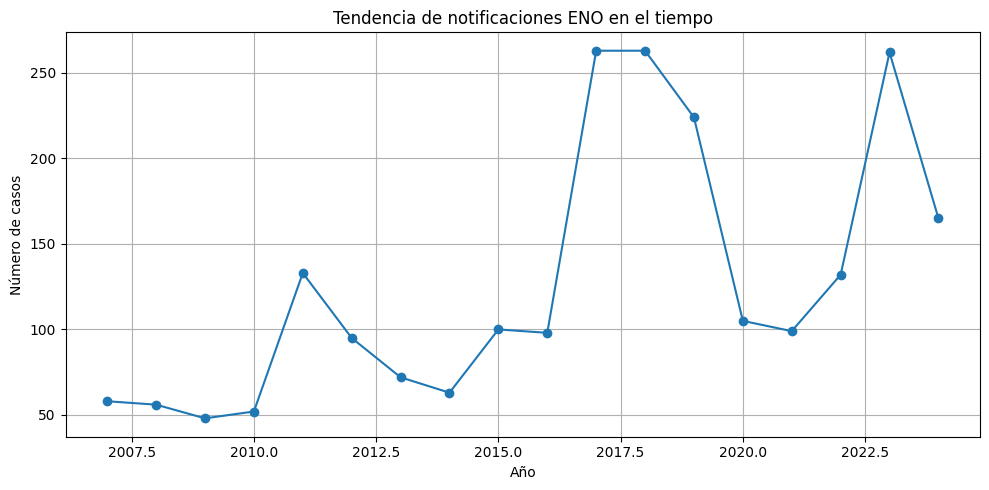


PARTE 1.2: TENDENCIA POR NACIONALIDAD
nacionalidad       Chile  Extranjero
anho_notificacion                   
2007                14.0         5.0
2008                13.0         0.0
2009                24.0         1.0
2010                20.0         2.0
2011                51.0         2.0


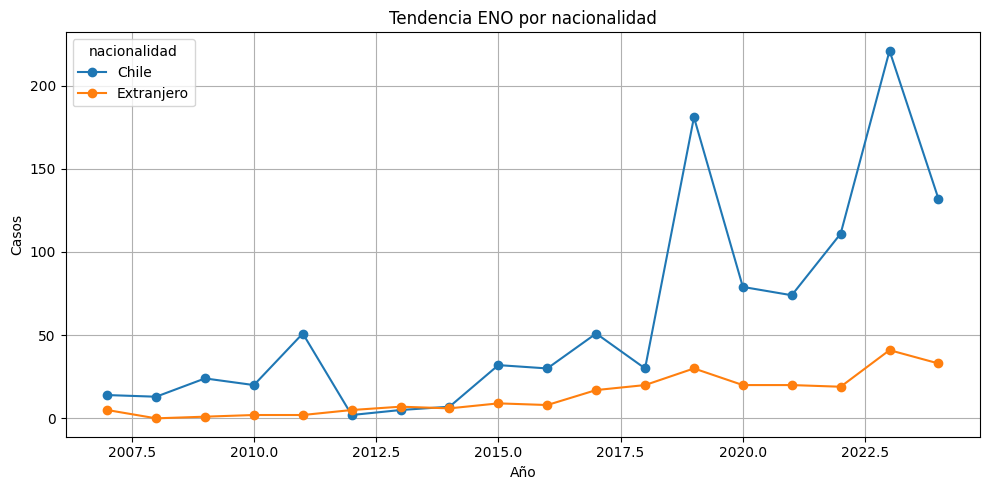

In [ ]:
# ============================================================
# CÓDIGO 2: PARTE 1 - TENDENCIAS EN EL TIEMPO
# ============================================================

# ------------------------------------------------------------
# 1.1 TENDENCIA TOTAL DE NOTIFICACIONES
# ------------------------------------------------------------
# Este gráfico muestra cómo cambian las notificaciones ENO a lo largo del tiempo.
# Sirve para detectar aumentos, caídas o años con comportamiento atípico.

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    notificaciones_por_anio["anho_notificacion"],
    notificaciones_por_anio["cantidad"],
    marker="o"
)

ax.set_title("Tendencia de notificaciones ENO en el tiempo")
ax.set_xlabel("Año")
ax.set_ylabel("Número de casos")
ax.grid(True)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------
# 1.2 TENDENCIA POR NACIONALIDAD
# ------------------------------------------------------------
# En esta base, la variable 'nacionalidad' solo tiene dos categorías válidas:
# 'Chile' y 'Extranjero'. Por eso no corresponde hablar de "Top 3";
# lo correcto es comparar directamente ambos grupos en el tiempo.

tabla_nac = (
    eno_nat.groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="cantidad")
)

# Se transforma la tabla a formato ancho para que cada categoría
# quede como una columna y ambas series puedan graficarse juntas.

pivot_nac = (
    tabla_nac.pivot(
        index="anho_notificacion",
        columns="nacionalidad",
        values="cantidad"
    )
    .fillna(0)
)

print("\n" + "=" * 60)
print("PARTE 1.2: TENDENCIA POR NACIONALIDAD")
print(pivot_nac.head())

# Se ordenan las columnas para mantener una lectura consistente en el gráfico:
# primero Chile y luego Extranjero, siempre que ambas existan.

columnas_ordenadas = [col for col in ["Chile", "Extranjero"] if col in pivot_nac.columns]
pivot_nac = pivot_nac[columnas_ordenadas]

ax = pivot_nac.plot(figsize=(10, 5), marker="o")

ax.set_title("Tendencia ENO por nacionalidad")
ax.set_xlabel("Año")
ax.set_ylabel("Casos")
ax.grid(True)
plt.tight_layout()
plt.show()

La tendencia temporal revela si las notificaciones han aumentado o disminuido a lo largo del período. Un aumento sostenido puede reflejar mayor cobertura del sistema de vigilancia epidemiológica o la aparición de nuevos brotes. La desagregación por nacionalidad permite observar si los patrones de notificación difieren entre chilenos y extranjeros a lo largo del tiempo.

---
### Parte 2 — Perfil de los casos

Esta sección caracteriza a las personas notificadas en el ENO según tres dimensiones: sexo, grupo etario y nivel educacional.

#### 2.1 Distribución por sexo
Permite identificar si existe una brecha de género en las enfermedades notificadas. Algunas enfermedades como las ITS pueden mostrar patrones muy diferenciados por sexo.

#### 2.2 Distribución por grupo etario
Identifica qué grupos de edad concentran más notificaciones, orientando políticas de salud pública focalizadas.

#### 2.3 Nivel educacional
Se usa como proxy socioeconómico. Se excluyen las categorías `"Desconocido"`, `"No responde"` y `"No recuerda"` por ser no informativas para el análisis.


PARTE 2.1: DISTRIBUCIÓN POR SEXO
     sexo  cantidad
0  hombre      1471
1   mujer       816
2     ***         1


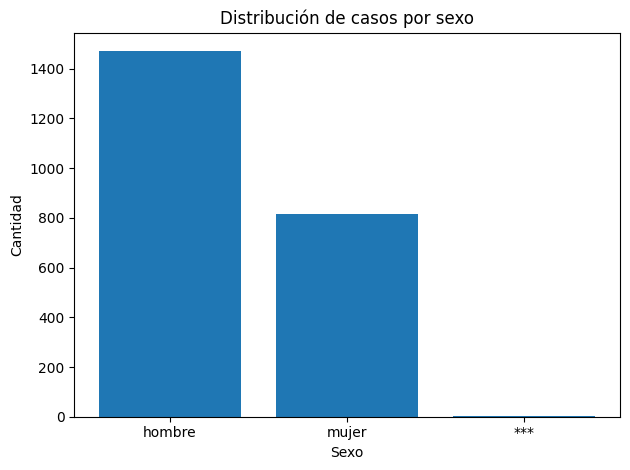


PARTE 2.2: DISTRIBUCIÓN POR GRUPO ETARIO
grupo_edad
***        1
00-04    214
05-09    145
10-14     93
15-19     77
20-24    232
25-29    316
30-34    307
35-39    203
40-44    160
45-49    142
50-54    109
55-59     97
60-64     64
65-69     43
70-74     36
75-79     24
80y+      25
Name: count, dtype: int64


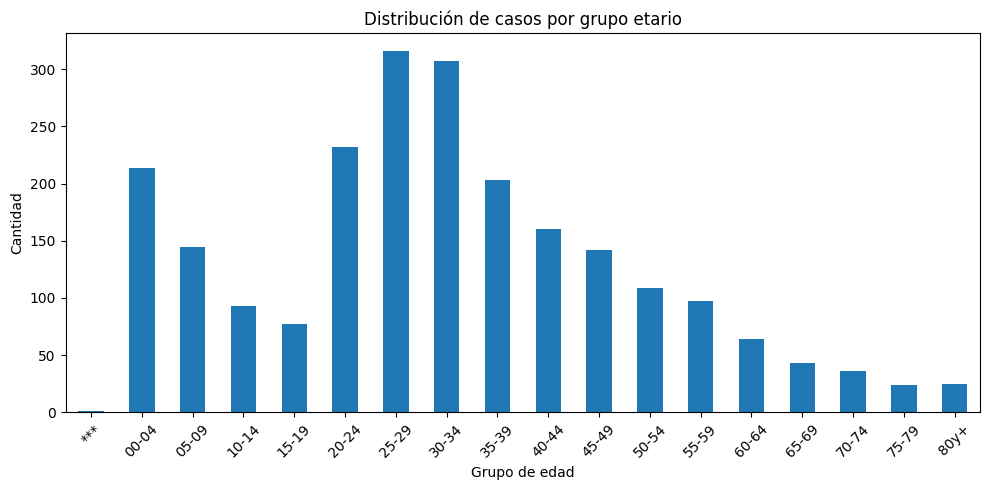


PARTE 2.3: NIVEL EDUCACIONAL
nombre_instruccion
PROFESIONAL UNIVERSITARIO    298
MEDIA                         77
BÁSICA                        53
TÉCNICO DE NIVEL SUPERIOR     42
NO RESPONDE                   36
SIN INSTRUCCIÓN               22
PREBÁSICA                     13
NO RECUERDA                    2
Name: count, dtype: int64


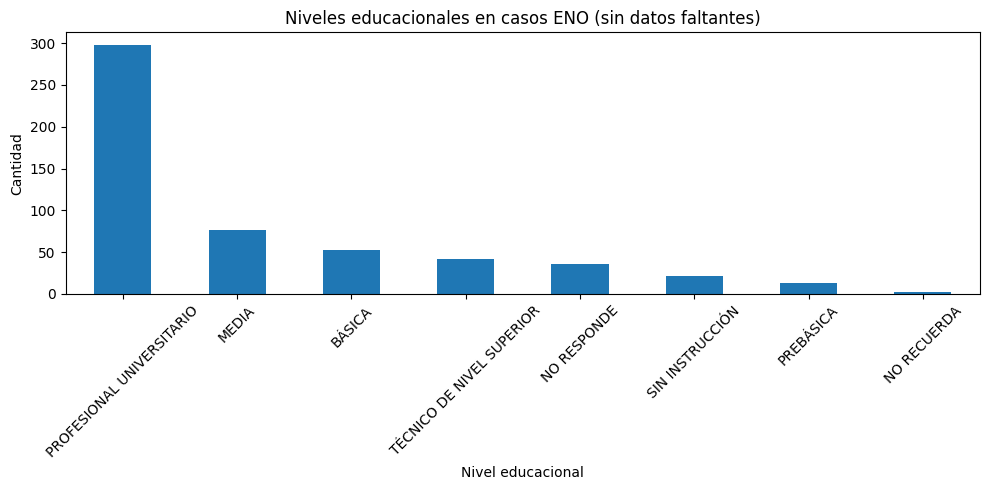

In [ ]:
# ============================================================
# CÓDIGO 3: PARTE 2 - PERFIL DE LOS CASOS
# ============================================================

# ------------------------------------------------------------
# 2.1 DISTRIBUCIÓN POR SEXO
# ------------------------------------------------------------
# Aquí resumimos cuántos casos hay en cada categoría de sexo.
# Esto permite describir la composición general de la muestra.

sexo_tabla = (
    eno_com["sexo"]
    .value_counts(dropna=False)
    .reset_index(name="cantidad")
    .rename(columns={"index": "sexo"})
)

print("\n" + "=" * 60)
print("PARTE 2.1: DISTRIBUCIÓN POR SEXO")
print(sexo_tabla)

fig, ax = plt.subplots()

ax.bar(sexo_tabla["sexo"].astype(str), sexo_tabla["cantidad"])
ax.set_title("Distribución de casos por sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2.2 DISTRIBUCIÓN POR GRUPO ETARIO
# ------------------------------------------------------------
# Este bloque permite ver cómo se concentran los casos según grupo de edad.
# Se ordena por índice para respetar el orden natural de las categorías.

edad_tabla = (
    eno_com["grupo_edad"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\n" + "=" * 60)
print("PARTE 2.2: DISTRIBUCIÓN POR GRUPO ETARIO")
print(edad_tabla)

fig, ax = plt.subplots(figsize=(10, 5))

edad_tabla.plot(kind="bar", ax=ax)

ax.set_title("Distribución de casos por grupo etario")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2.3 NIVEL EDUCACIONAL
#    Se eliminan categorías no informativas para evitar sesgo
# ------------------------------------------------------------
# Para este análisis se excluyen respuestas que no permiten
# identificar realmente el nivel educacional del caso.

edu_limpio = eno_com[
    ~eno_com["nombre_instruccion"].isin([
        "Desconocido",
        "No responde",
        "No recuerda"
    ])
].copy()

edu_tabla = edu_limpio["nombre_instruccion"].value_counts()

print("\n" + "=" * 60)
print("PARTE 2.3: NIVEL EDUCACIONAL")
print(edu_tabla)

fig, ax = plt.subplots(figsize=(10, 5))

edu_tabla.plot(kind="bar", ax=ax)

ax.set_title("Niveles educacionales en casos ENO (sin datos faltantes)")
ax.set_xlabel("Nivel educacional")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


La distribución por sexo y edad revela los grupos más vulnerables a las enfermedades notificables en estas comunas. El nivel educacional como proxy socioeconómico puede revelar mayor concentración de casos en grupos con menor acceso a servicios preventivos. Diferencias marcadas entre grupos orientan dónde focalizar intervenciones de salud pública.
---
### Parte 3 — Análisis espacial y tasas de notificación

#### 3.1 Casos ENO por comuna
Conteo absoluto de notificaciones por cada comuna asignada.

#### 3.2 Población desde Censo
Se carga la población de cada comuna desde el Censo 2024 para calcular tasas comparables.

#### 3.3 Tasa ENO por 1.000 habitantes
Los casos absolutos no son directamente comparables entre comunas de distinto tamaño. La tasa por 1.000 habitantes permite una comparación equitativa:

> **Fórmula:** Tasa = (Casos ENO / Población) × 1.000

#### 3.4 y 3.5 Mapa coroplético
Se integra la información con el shapefile oficial de comunas para visualizar espacialmente las diferencias en tasas de notificación.


PARTE 3.1: CASOS POR COMUNA
   comuna  casos nombre_comuna
0   13114   2123    Las Condes
1   13503    165      Curacaví

Población por comuna:
   comuna  poblacion nombre_comuna
0   13114     296134    Las Condes
1   13503      35165      Curacaví

Tabla con tasa ENO:
   comuna  casos nombre_comuna  poblacion  tasa_eno
0   13114   2123    Las Condes     296134  7.169052
1   13503    165      Curacaví      35165  4.692166

Merge espacial:
   CUT_COM      COMUNA  casos  poblacion  tasa_eno
0    13503    Curacaví    165      35165  4.692166
1    13114  Las Condes   2123     296134  7.169052


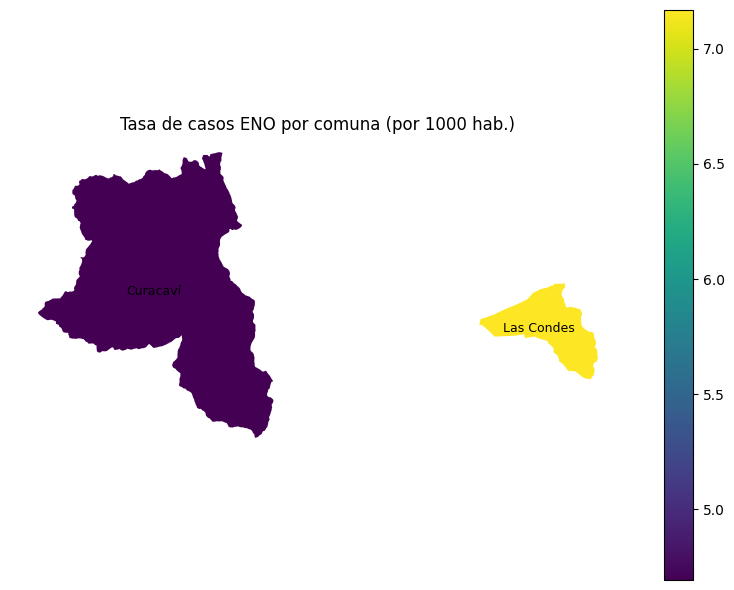

In [ ]:
# ============================================================
# PARTE 3: ANÁLISIS ESPACIAL Y TASAS
# ============================================================

# ------------------------------------------------------------
# 3.1 CASOS ENO POR COMUNA
# ------------------------------------------------------------
# Contamos los casos ENO por comuna. Se usa rename_axis("comuna")
# para que la columna resultante quede bien nombrada desde el inicio
# y así evitar errores como KeyError al momento de usarla después.

casos_comuna = (
    eno_com["codigo_comuna_residencia"]
    .value_counts()
    .rename_axis("comuna")
    .reset_index(name="casos")
)

# Se convierte la comuna a número para que pueda coincidir correctamente
# con los códigos del censo y del shapefile.
casos_comuna["comuna"] = pd.to_numeric(casos_comuna["comuna"], errors="coerce")

# Si alguna comuna no pudo convertirse a número, se elimina para evitar
# que provoque errores en merges posteriores.
casos_comuna = casos_comuna.dropna(subset=["comuna"]).copy()
casos_comuna["comuna"] = casos_comuna["comuna"].astype(int)

# Se agrega el nombre de la comuna para facilitar la lectura.
casos_comuna["nombre_comuna"] = casos_comuna["comuna"].map(MAPA_COMUNAS)

print("\n" + "=" * 60)
print("PARTE 3.1: CASOS POR COMUNA")
print(casos_comuna)

# ------------------------------------------------------------
# 3.2 CARGAR LA POBLACIÓN REAL DESDE EL CENSO
# ------------------------------------------------------------
# Se carga solo la columna necesaria para mantener el proceso liviano.

persona_censo = pd.read_csv(
    os.path.join(RUTA_BASE, "personas_censo2024.csv"),
    sep=";",
    usecols=["comuna"]
)

# Se normaliza el tipo de dato para asegurar que el filtro funcione bien.
persona_censo["comuna"] = pd.to_numeric(persona_censo["comuna"], errors="coerce")
persona_censo = persona_censo.dropna(subset=["comuna"]).copy()
persona_censo["comuna"] = persona_censo["comuna"].astype(int)

# Se filtran únicamente las comunas del estudio.
persona_censo = persona_censo[
    persona_censo["comuna"].isin(MY_COMUNAS)
].copy()

# Como cada fila representa una persona, contar filas por comuna
# entrega la población observada en esa comuna dentro del archivo censal.
fer_poblacion = (
    persona_censo.groupby("comuna")
    .size()
    .reset_index(name="poblacion")
)

fer_poblacion["nombre_comuna"] = fer_poblacion["comuna"].map(MAPA_COMUNAS)

print("\nPoblación por comuna:")
print(fer_poblacion)

# ------------------------------------------------------------
# 3.3 CALCULAR TASA ENO POR 1000 HABITANTES
# ------------------------------------------------------------
# Se unen los casos con la población para calcular una tasa comparable
# entre comunas, independiente de su tamaño poblacional.

casos_tasa = casos_comuna.merge(
    fer_poblacion[["comuna", "poblacion"]],
    on="comuna",
    how="left"
)

# Esta validación evita que el cálculo continúe con comunas sin población,
# lo que podría generar tasas erróneas o valores nulos inesperados.
faltan_poblacion = casos_tasa["poblacion"].isna().sum()
if faltan_poblacion > 0:
    raise ValueError("Hay comunas sin población asociada. Revisa el cruce con personas_censo2024.csv.")

casos_tasa["tasa_eno"] = (
    casos_tasa["casos"] / casos_tasa["poblacion"] * 1000
)

# Se vuelve a mapear el nombre por claridad final.
casos_tasa["nombre_comuna"] = casos_tasa["comuna"].map(MAPA_COMUNAS)

print("\nTabla con tasa ENO:")
print(casos_tasa)

# ------------------------------------------------------------
# 3.4 CARGAR SHAPEFILE Y HACER MERGE ESPACIAL
# ------------------------------------------------------------
# Se carga el shapefile de comunas y se normaliza el código comunal
# para que el merge espacial funcione sin problemas de tipo de dato.
ruta_shape = os.path.join(RUTA_COMUNAS, "COMUNAS_v1.shp")
gdf = gpd.read_file(ruta_shape)

gdf["CUT_COM"] = pd.to_numeric(gdf["CUT_COM"], errors="coerce")
gdf = gdf.dropna(subset=["CUT_COM"]).copy()
gdf["CUT_COM"] = gdf["CUT_COM"].astype(int)

# Se puede filtrar el shapefile solo a las comunas de interés para
# hacer el proceso más limpio y directo.
gdf = gdf[gdf["CUT_COM"].isin(MY_COMUNAS)].copy()

gdf_merge_tasa = gdf.merge(
    casos_tasa,
    left_on="CUT_COM",
    right_on="comuna",
    how="inner"
)

# Si el merge espacial no devuelve filas, es mejor detenerse de inmediato
# para no seguir con un mapa vacío o engañoso.
if gdf_merge_tasa.empty:
    raise ValueError("El merge espacial quedó vacío. Revisa códigos comunales entre casos, censo y shapefile.")

print("\nMerge espacial:")
print(gdf_merge_tasa[["CUT_COM", "COMUNA", "casos", "poblacion", "tasa_eno"]])

# ------------------------------------------------------------
# 3.5 MAPA DE TASA ENO
# ------------------------------------------------------------
# El mapa muestra la tasa ENO por 1000 habitantes, que es una medida
# más comparable que usar solo el número bruto de casos.
fig, ax = plt.subplots(figsize=(8, 6))

gdf_merge_tasa.plot(
    column="tasa_eno",
    legend=True,
    ax=ax
)

ax.set_title("Tasa de casos ENO por comuna (por 1000 hab.)")
ax.axis("off")

# Se usan puntos representativos de cada polígono para ubicar etiquetas
# en una posición más estable que el centroide en geometrías complejas.
for _, row in gdf_merge_tasa.iterrows():
    punto = row.geometry.representative_point()
    ax.text(
        punto.x,
        punto.y,
        row["COMUNA"],
        fontsize=9,
        ha="center"
    )

plt.tight_layout()
plt.show()

La tasa de notificación por 1.000 habitantes permite comparar equitativamente Las Condes y Curacaví independientemente de su diferencia de tamaño poblacional. Una tasa mayor puede reflejar mayor incidencia real, pero también mejor acceso al sistema de salud y mayor detección de casos.

---
### Parte 4 — Tabla resumen comunal ENO

Se construye una tabla agregada a nivel de comuna con los principales indicadores ENO. Esta tabla será reutilizada en la **Tarea 3** para el análisis de regresión ecológica cross-dataset.

Indicadores incluidos:
- `casos`: total de notificaciones ENO 2007-2024
- `tasa_eno`: notificaciones por 1.000 habitantes
- `pct_extranjeros`: proporción de notificaciones en personas extranjeras (excluye "Desconocido")
- `edu_dominante`: nivel educacional más frecuente entre los casos notificados

In [ ]:
# ============================================================
# PARTE 4: TABLA RESUMEN COMUNAL ENO
# ============================================================

# ------------------------------------------------------------
# 4.1 TOTAL DE CASOS
# ------------------------------------------------------------
casos = (
    eno_com.groupby("codigo_comuna_residencia")
    .size()
    .rename_axis("comuna")
    .reset_index(name="casos")
)

casos["comuna"] = pd.to_numeric(casos["comuna"], errors="coerce")
casos = casos.dropna(subset=["comuna"]).copy()
casos["comuna"] = casos["comuna"].astype(int)

# ------------------------------------------------------------
# 4.2 % DE EXTRANJEROS EN ENO
#    Para este cálculo se excluye "Desconocido"
# ------------------------------------------------------------
extranj = (
    eno_nat.groupby("codigo_comuna_residencia")["nacionalidad"]
    .apply(lambda x: (x == "Extranjero").mean())
    .rename_axis("comuna")
    .reset_index(name="pct_extranjeros")
)

extranj["comuna"] = pd.to_numeric(extranj["comuna"], errors="coerce")
extranj = extranj.dropna(subset=["comuna"]).copy()
extranj["comuna"] = extranj["comuna"].astype(int)

# ------------------------------------------------------------
# 4.3 NIVEL EDUCACIONAL DOMINANTE
# ------------------------------------------------------------
# Se excluyen categorías no informativas para que el nivel dominante
# represente mejor la distribución real observada en cada comuna.
fer_dom = (
    eno_com[
        ~eno_com["nombre_instruccion"].isin([
            "Desconocido",
            "No responde",
            "No recuerda"
        ])
    ]
    .groupby("codigo_comuna_residencia")["nombre_instruccion"]
    .agg(lambda x: x.value_counts().idxmax())
    .rename_axis("comuna")
    .reset_index(name="fer_dominante")
)

fer_dom["comuna"] = pd.to_numeric(fer_dom["comuna"], errors="coerce")
fer_dom = fer_dom.dropna(subset=["comuna"]).copy()
fer_dom["comuna"] = fer_dom["comuna"].astype(int)

# ------------------------------------------------------------
# 4.4 ASEGURAR TIPOS CONSISTENTES EN casos_tasa
# ------------------------------------------------------------
casos_tasa["comuna"] = pd.to_numeric(casos_tasa["comuna"], errors="coerce")
casos_tasa = casos_tasa.dropna(subset=["comuna"]).copy()
casos_tasa["comuna"] = casos_tasa["comuna"].astype(int)

# ------------------------------------------------------------
# 4.5 UNIR TODO EN UNA SOLA TABLA
# ------------------------------------------------------------
# Aquí se consolidan los principales indicadores por comuna
# en una sola tabla resumen.
resumen_eno = (
    casos
    .merge(casos_tasa[["comuna", "tasa_eno"]], on="comuna", how="left")
    .merge(extranj, on="comuna", how="left")
    .merge(fer_dom, on="comuna", how="left")
)

# ------------------------------------------------------------
# 4.6 AGREGAR NOMBRE DE COMUNA
# ------------------------------------------------------------
resumen_eno["nombre_comuna"] = resumen_eno["comuna"].map(MAPA_COMUNAS)

# ------------------------------------------------------------
# 4.7 ORDENAR COLUMNAS
# ------------------------------------------------------------
resumen_eno = resumen_eno[
    [
        "comuna",
        "nombre_comuna",
        "casos",
        "tasa_eno",
        "pct_extranjeros",
        "fer_dominante"
    ]
].sort_values("comuna").reset_index(drop=True)

# ------------------------------------------------------------
# 4.8 REDONDEAR RESULTADOS
# ------------------------------------------------------------
resumen_eno["tasa_eno"] = resumen_eno["tasa_eno"].round(2)
resumen_eno["pct_extranjeros"] = (resumen_eno["pct_extranjeros"] * 100).round(2)

# ------------------------------------------------------------
# 4.9 MOSTRAR TABLA FINAL
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("PARTE 4: TABLA RESUMEN ENO")
print(resumen_eno)

# ------------------------------------------------------------
# 4.10 EXPORTAR A CSV
# ------------------------------------------------------------
os.makedirs(RUTA_OUTPUT, exist_ok=True)

ruta_salida = os.path.join(RUTA_OUTPUT, "resumen_eno_comunas.csv")
resumen_eno.to_csv(ruta_salida, index=False)

print(f"\nArchivo guardado en:\n{ruta_salida}")


PARTE 4: TABLA RESUMEN ENO
   comuna nombre_comuna  casos  tasa_eno  pct_extranjeros  \
0   13114    Las Condes   2123      7.17            19.23   
1   13503      Curacaví    165      4.69            11.57   

               fer_dominante  
0  PROFESIONAL UNIVERSITARIO  
1                      MEDIA  

Archivo guardado en:
/content/drive/MyDrive/ColabNotebooks/output/resumen_eno_comunas.csv


La tabla resumen ENO queda guardada como `resumen_eno_comunas.csv`. Las diferencias en tasa de notificación y porcentaje de extranjeros entre Las Condes y Curacaví reflejan las distintas características demográficas y de acceso al sistema de salud de cada comuna.

---
## Bloque B — GRD (Egresos Hospitalarios)

### Parte 0 — Carga y limpieza inicial

#### Desafíos técnicos del dataset GRD

Los archivos GRD presentan varios desafíos que requieren funciones auxiliares especializadas:

- **Encoding variable por año:** los archivos pueden estar en `utf-16`, `utf-16-le`, `utf-16-be` o `latin-1`. Se detecta y prueba automáticamente cada uno.
- **Nombres de columnas con caracteres extraños:** los encabezados a veces contienen caracteres BOM (`\ufeff`) o nulos (`\x00`). Se normalizan automáticamente.
- **Un archivo ZIP por año:** se cargan los años 2022, 2023 y 2024 y se concatenan en un único DataFrame.
- **129 columnas por archivo:** se cargan solo las columnas necesarias usando `usecols` para eficiencia de memoria.

#### Pipeline de carga (pasos 0.1 a 0.3)
1. Detectar encoding y columnas en cada ZIP
2. Cargar solo columnas necesarias
3. Concatenar los tres años en un DataFrame unificado

In [ ]:
# ============================================================
# TAREA 2 - GRD
# PARTE 0: CARGA Y LIMPIEZA INICIAL
# ============================================================

import os
import io
import re
import zipfile
import warnings
import unicodedata
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 0.0 CONFIGURACIÓN
# ------------------------------------------------------------
RUTA_BASE = "/content/drive/MyDrive/ColabNotebooks/"
RUTA_GRD = os.path.join(RUTA_BASE, "GRD")

MY_COMUNA_NAMES = ["LAS CONDES", "CURACAVI"]

# ------------------------------------------------------------
# 0.1 FUNCIONES AUXILIARES
# ------------------------------------------------------------
def limpiar_texto(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def normalizar_columna(col):
    col = str(col)
    col = col.replace("\ufeff", "")
    col = col.replace("ÿþ", "")
    col = col.replace("\x00", "")
    col = re.sub(r"\s+", " ", col)
    col = col.strip().upper()
    return col

def buscar_txt_en_zip(zippath):
    with zipfile.ZipFile(zippath) as z:
        txt_candidates = [
            n for n in z.namelist()
            if n.lower().endswith(".txt") and not n.endswith("/")
        ]

    if not txt_candidates:
        raise FileNotFoundError(f"No se encontró ningún .txt dentro de {zippath}")

    return txt_candidates[0]

def leer_preview_con_encoding(zippath, txtname, encoding, nrows=5):
    with zipfile.ZipFile(zippath) as z:
        with z.open(txtname) as fbin:
            wrapper = io.TextIOWrapper(
                fbin,
                encoding=encoding,
                errors="ignore",
                newline=""
            )
            df = pd.read_csv(
                wrapper,
                sep="|",
                nrows=nrows,
                low_memory=False,
                on_bad_lines="skip"
            )
    return df

def detectar_encoding_y_columnas(zippath, columnas_requeridas):
    txtname = buscar_txt_en_zip(zippath)
    encodings_a_probar = ["utf-16", "utf-16-le", "utf-16-be", "latin-1"]

    for enc in encodings_a_probar:
        try:
            df_preview = leer_preview_con_encoding(zippath, txtname, enc, nrows=5)
            columnas_originales = list(df_preview.columns)
            columnas_norm = [normalizar_columna(c) for c in columnas_originales]
            mapa_cols = dict(zip(columnas_norm, columnas_originales))

            faltantes = [c for c in columnas_requeridas if c not in mapa_cols]
            if not faltantes:
                return txtname, enc, mapa_cols

        except Exception:
            continue

    raise ValueError(
        f"No se pudo detectar un encoding válido para {zippath} "
        f"que contenga todas las columnas requeridas."
    )

def leer_grd_anio(zippath, columnas_requeridas):
    # Primero se detecta el .txt correcto dentro del zip, el encoding
    # y el nombre real de las columnas presentes en ese archivo.
    txtname, encoding_ok, mapa_cols = detectar_encoding_y_columnas(
        zippath,
        columnas_requeridas
    )

    usecols_reales = [mapa_cols[c] for c in columnas_requeridas]

    with zipfile.ZipFile(zippath) as z:
        with z.open(txtname) as fbin:
            wrapper = io.TextIOWrapper(
                fbin,
                encoding=encoding_ok,
                errors="ignore",
                newline=""
            )
            df = pd.read_csv(
                wrapper,
                sep="|",
                usecols=usecols_reales,
                low_memory=False,
                on_bad_lines="skip"
            )

    df.columns = [normalizar_columna(c) for c in df.columns]
    return df

# ------------------------------------------------------------
# 0.2 COLUMNAS NECESARIAS
# ------------------------------------------------------------
grd_cols_deseadas = [
    "COMUNA",
    "NACIONALIDAD",
    "SEXO",
    "FECHA_NACIMIENTO",
    "FECHA_INGRESO",
    "FECHAALTA",
    "TIPOALTA",
    "DIAGNOSTICO1",
    "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD",
    "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD",
    "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

# ------------------------------------------------------------
# 0.3 CARGAR GRD 2022-2024
# ------------------------------------------------------------
frames = []
archivos = os.listdir(RUTA_GRD)

for year in [2022, 2023, 2024]:
    # Se busca el zip del año correspondiente e ignoramos otros formatos.
    candidatos = sorted(
        f for f in archivos
        if str(year) in f and f.lower().endswith(".zip")
    )

    if not candidatos:
        raise FileNotFoundError(f"No hay archivo .zip para el año {year}")

    zippath = os.path.join(RUTA_GRD, candidatos[0])

    df_year = leer_grd_anio(zippath, grd_cols_deseadas)
    df_year["YEAR"] = year
    frames.append(df_year)

# Se consolidan los tres años en una sola base.
grd = pd.concat(frames, ignore_index=True)

print(f"Total discharges (3 years): {len(grd):,}")

Total discharges (3 years): 3,058,240


**Resultado esperado:** El dataset GRD consolidado cubre 3 años de egresos hospitalarios (2022-2024). La función de carga robusta maneja automáticamente las diferencias de encoding entre archivos de distintos años.

#### 0.4 a 0.7 Filtro, LOS, nacionalidad y join CIE-10

- **0.4 Filtrar comunas:** se filtra por nombre de comuna en mayúsculas (`"LAS CONDES"`, `"CURACAVI"`). Se normaliza el texto para evitar problemas con tildes o espacios.
- **0.5 Longitud de estadía (LOS):** se calcula como diferencia en días entre fecha de ingreso y fecha de alta. Los valores negativos (errores de digitación) se eliminan y se reporta cuántos fueron removidos.
- **0.6 Grupo de nacionalidad:** se crea la variable `nat_group` (`"Chilean"` vs `"Foreign"`) basada en si la nacionalidad registrada es `"CHILE"` o cualquier otra.
- **0.7 Join con CIE-10:** se une `DIAGNOSTICO1` con la tabla CIE-10 para obtener descripciones legibles de los diagnósticos. Se reporta cuántos registros no hicieron match.

In [ ]:
# ------------------------------------------------------------
# 0.4 FILTRAR A COMUNAS
# El enunciado pide:
# - Discharges in my comunas
# - Number of discharges per year in my comunas
# ------------------------------------------------------------
grd["COMUNA_CLEAN"] = grd["COMUNA"].apply(limpiar_texto)

grd_com = grd[
    grd["COMUNA_CLEAN"].isin(MY_COMUNA_NAMES)
].copy()

print(f"Discharges in my comunas: {len(grd_com):,}")

egresos_por_anio = (
    grd_com["YEAR"]
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="discharges")
)

print("\nDischarges per year in my comunas:")
print(egresos_por_anio)

# ------------------------------------------------------------
# 0.5 CALCULAR LONGITUD DE ESTADÍA (LOS)
# El enunciado pide:
# - mean, median, min, max
# - cuántas filas con los < 0 se removieron
# ------------------------------------------------------------
# Se convierten las fechas antes de calcular la estadía.

grd_com["fecha_ingreso_dt"] = pd.to_datetime(
    grd_com["FECHA_INGRESO"],
    errors="coerce"
)

grd_com["fecha_alta_dt"] = pd.to_datetime(
    grd_com["FECHAALTA"],
    errors="coerce"
)

grd_com["los"] = (
    grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]
).dt.days

neg_los = (grd_com["los"] < 0).sum()

los_stats = grd_com["los"].agg(["mean", "median", "min", "max"])

print("\nLOS distribution (before removing negative values):")
print(los_stats)

print(f"\nRows removed where los < 0: {neg_los:,}")

# Se eliminan solo LOS negativos; los NaN se mantienen.
grd_com = grd_com[
    grd_com["los"].isna() | (grd_com["los"] >= 0)
].copy()

# ------------------------------------------------------------
# 0.6 CREAR GRUPO DE NACIONALIDAD
# El enunciado pide:
# - distribución de nat_group
# ------------------------------------------------------------
grd_com["NACIONALIDAD_CLEAN"] = grd_com["NACIONALIDAD"].apply(limpiar_texto)

grd_com["nat_group"] = np.where(
    grd_com["NACIONALIDAD_CLEAN"] == "CHILE",
    "Chilean",
    "Foreign"
)

print("\nDistribution of nat_group:")
print(grd_com["nat_group"].value_counts(dropna=False))

# ============================================================
# 0.7 JOIN CON CIE-10
# ============================================================
def normalizar_excel_col(col):
    col = str(col).strip().upper()
    col = unicodedata.normalize("NFKD", col).encode("ascii", "ignore").decode("utf-8")
    col = re.sub(r"\s+", " ", col)
    return col

ruta_cie10 = os.path.join(RUTA_GRD, "CIE-10.xlsx")

if not os.path.exists(ruta_cie10):
    raise FileNotFoundError(f"No se encontró el archivo: {ruta_cie10}")

xls = pd.ExcelFile(ruta_cie10)

cie10 = None
col_codigo = None
col_desc = None
col_cap = None

for hoja in xls.sheet_names:
    df_try = pd.read_excel(ruta_cie10, sheet_name=hoja)
    cols_norm = [normalizar_excel_col(c) for c in df_try.columns]
    mapa_cols = dict(zip(cols_norm, df_try.columns))

    posibles_codigo = [c for c in mapa_cols if "COD" in c]
    posibles_desc = [c for c in mapa_cols if "DESC" in c]
    posibles_cap = [c for c in mapa_cols if "CAP" in c]

    if posibles_codigo and posibles_desc and posibles_cap:
        cie10 = df_try.copy()
        col_codigo = mapa_cols[posibles_codigo[0]]
        col_desc = mapa_cols[posibles_desc[0]]
        col_cap = mapa_cols[posibles_cap[0]]
        break

if cie10 is None:
    raise ValueError(
        "No se pudo detectar automáticamente la hoja/columnas correctas en CIE-10.xlsx"
    )

cie10_small = (
    cie10[[col_codigo, col_desc, col_cap]]
    .dropna(subset=[col_codigo])
    .drop_duplicates(subset=[col_codigo])
    .copy()
)

cie10_small.columns = ["CODIGO", "DESCRIPCION", "CAPITULO"]

# Se limpian las claves antes del cruce para evitar fallas por formato.
grd_com["DIAGNOSTICO1"] = grd_com["DIAGNOSTICO1"].astype(str).str.strip().str.upper()
cie10_small["CODIGO"] = cie10_small["CODIGO"].astype(str).str.strip().str.upper()

grd_com = grd_com.merge(
    cie10_small,
    left_on="DIAGNOSTICO1",
    right_on="CODIGO",
    how="left"
)

no_match = grd_com["CAPITULO"].isna().sum()

print(f"\nRows failed to match CIE-10 lookup: {no_match:,}")

Discharges in my comunas: 15,872

Discharges per year in my comunas:
   year  discharges
0  2022        4919
1  2023        5421
2  2024        5532

LOS distribution (before removing negative values):
mean        6.105253
median      2.000000
min         0.000000
max       492.000000
Name: los, dtype: float64

Rows removed where los < 0: 0

Distribution of nat_group:
nat_group
Chilean    14715
Foreign     1157
Name: count, dtype: int64

Rows failed to match CIE-10 lookup: 2


**Nota sobre LOS negativo:** Valores negativos de LOS ocurren cuando la fecha de alta precede a la fecha de ingreso, lo que indica errores de digitación en el sistema de registro hospitalario. Se eliminan antes del análisis.

**Nota sobre el join CIE-10:** Si el porcentaje sin match es alto, puede deberse a diferencias de formato entre los códigos del GRD (sin punto, ej. `K358`) y los del CIE-10 (con punto, ej. `K35.8`).

---
### Parte 1 — Perfil diagnóstico

#### 1.1 Top capítulos diagnósticos
Los diagnósticos ICD-10 se organizan en capítulos temáticos (ej. "Enfermedades del aparato circulatorio", "Enfermedades del aparato digestivo"). Ver los capítulos más frecuentes identifica las principales causas de hospitalización en las comunas.

#### 1.2 Top diagnósticos específicos
A nivel más granular se muestran los 15 diagnósticos específicos más frecuentes, permitiendo identificar procedimientos o condiciones particulares que dominan los egresos.

#### 1.3 Capítulos por nacionalidad
Comparación de la distribución de capítulos entre pacientes chilenos y extranjeros usando barras apiladas al 100%. Permite identificar si existen diferencias en el perfil de enfermedades entre ambos grupos, lo que puede reflejar diferencias en acceso, condiciones laborales o perfiles de riesgo diferenciados.


PARTE 1.1: TOP CAPÍTULOS DIAGNÓSTICOS
CAPITULO
Cap.02  NEOPLASIAS (C00-D49)                                                                             2009
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)                                                     1959
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)         1849
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)                                                            1687
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)                                                  1634
Cap.07  ENFERMEDADES DEL OJO Y SUS ANEXOS (H00-H59)                                                      1232
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)                                                1190
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)                                                  1079
Cap.21  FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y CONTACTO CON LOS S

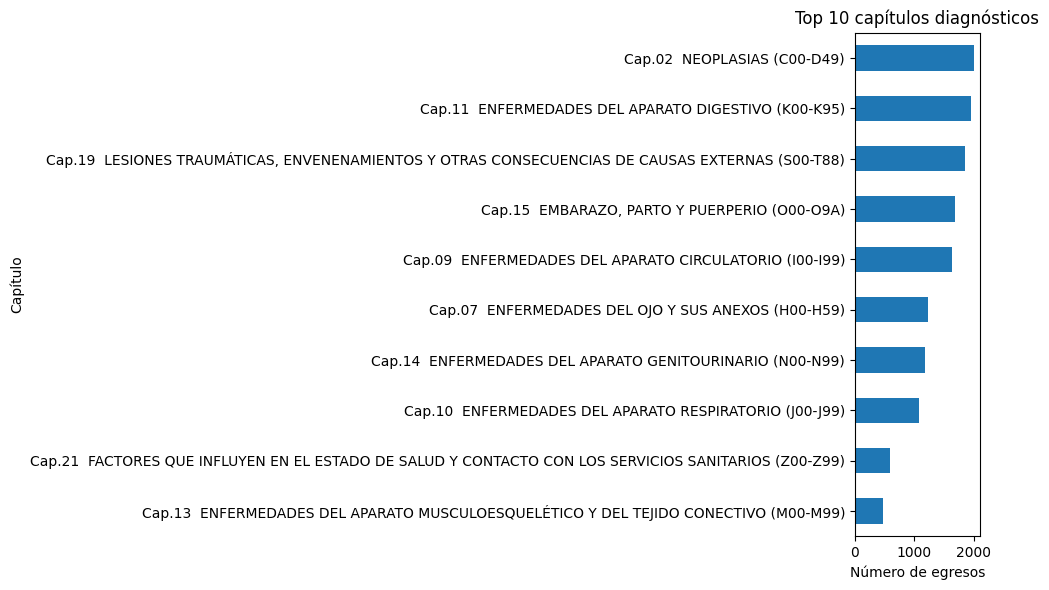


PARTE 1.2: TOP DIAGNÓSTICOS ESPECÍFICOS
DESCRIPCION
Catarata, no especificada                                                 770
Cálculo de la vesícula biliar sin colecistitis                            336
Apendicitis aguda, otra y no especificada                                 268
Fractura del cuello de fémur, cerrada                                     145
Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas    139
Sesión de quimioterapia por tumor                                         125
Catarata senil, no especificada                                           123
Enfermedad renal crónica, estadio 5                                       114
Prepucio redundante, fimosis y parafimosis                                111
Infarto subendocárdico agudo del miocardio                                108
Insuficiencia cardíaca congestiva                                         105
Cálculo de la vesícula biliar con colecistitis aguda                       95
Fractura de

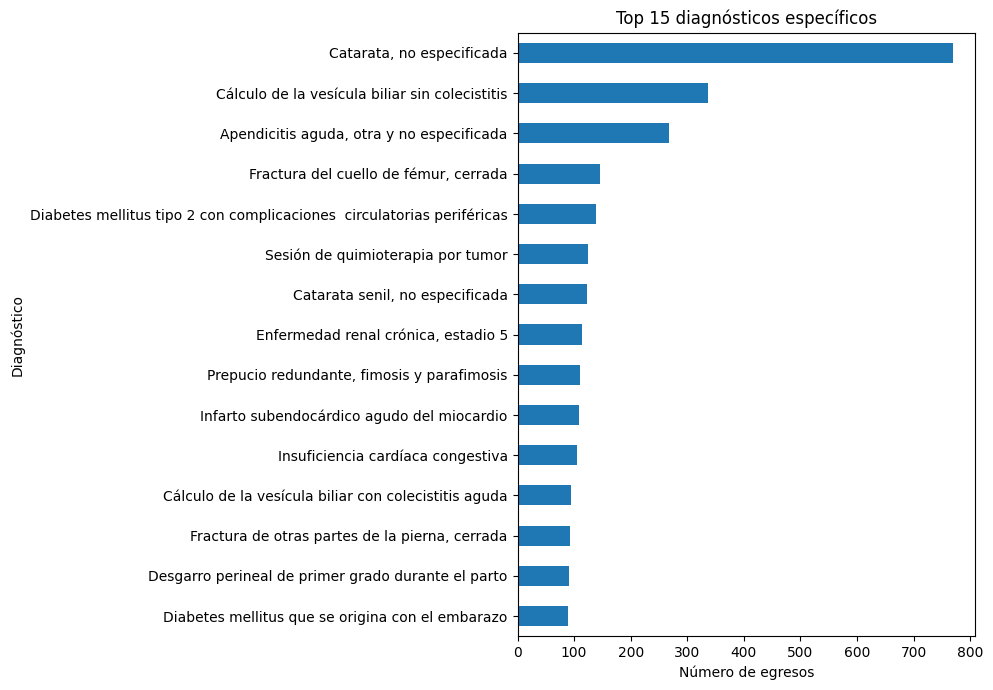


PARTE 1.3: CAPÍTULOS POR NACIONALIDAD
nat_group                                             Chilean    Foreign
CAPITULO                                                                
Cap.02  NEOPLASIAS (C00-D49)                        91.388751   8.611249
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (...  96.572827   3.427173
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00...  92.751404   7.248596
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)       78.660344  21.339656
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y...  95.186587   4.813413


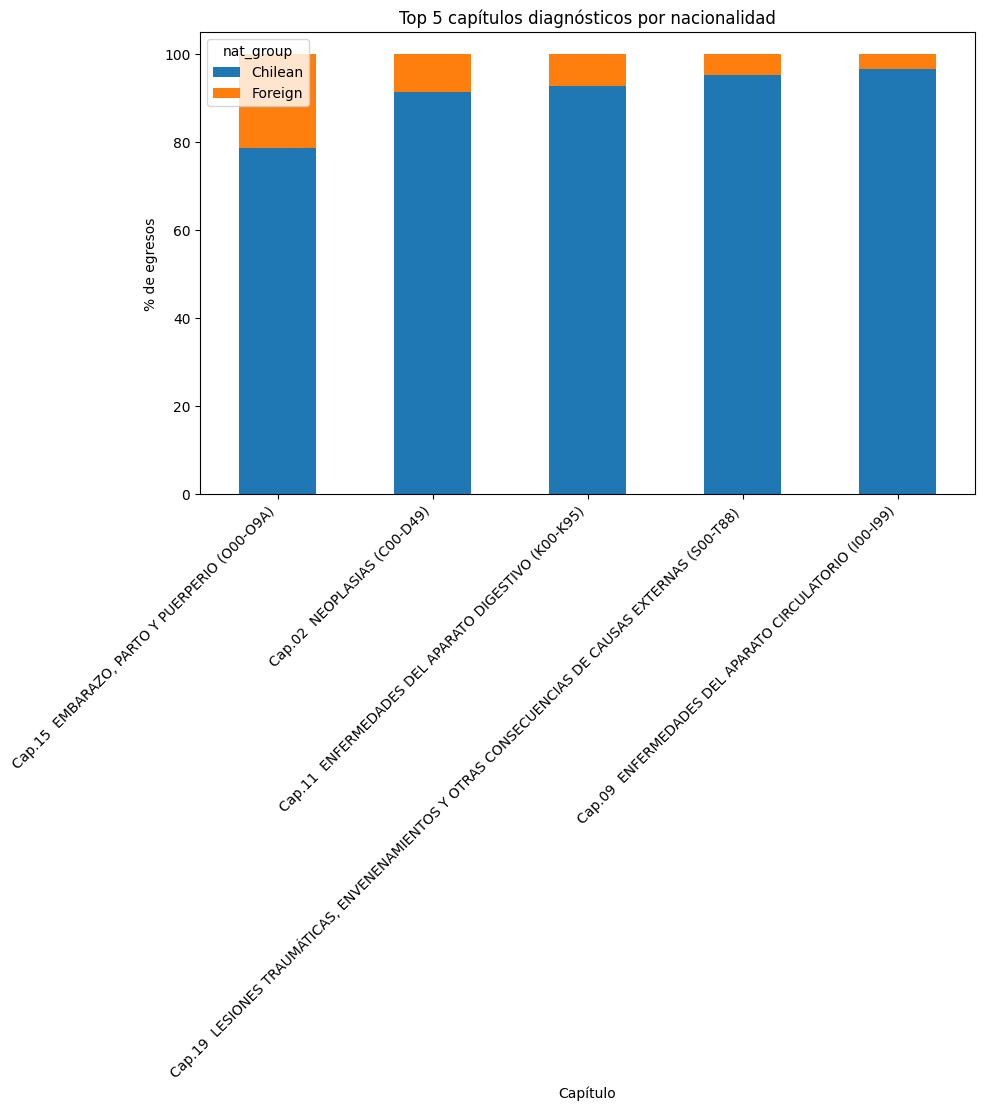

In [ ]:
# ============================================================
# PARTE 1: PERFIL DIAGNÓSTICO
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1.1 TOP CAPÍTULOS DIAGNÓSTICOS
# ------------------------------------------------------------
# Se completan nulos para no perder registros en el ranking.
top_cap = (
    grd_com["CAPITULO"]
    .fillna("Sin clasificar")
    .value_counts()
    .head(10)
)

print("\n" + "=" * 60)
print("PARTE 1.1: TOP CAPÍTULOS DIAGNÓSTICOS")
print(top_cap)

fig, ax = plt.subplots(figsize=(10, 6))

top_cap.sort_values().plot(kind="barh", ax=ax)

ax.set_title("Top 10 capítulos diagnósticos")
ax.set_xlabel("Número de egresos")
ax.set_ylabel("Capítulo")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 1.2 TOP DIAGNÓSTICOS ESPECÍFICOS
# ------------------------------------------------------------
top_diag = (
    grd_com["DESCRIPCION"]
    .fillna("Sin clasificar")
    .value_counts()
    .head(15)
)

print("\n" + "=" * 60)
print("PARTE 1.2: TOP DIAGNÓSTICOS ESPECÍFICOS")
print(top_diag)

fig, ax = plt.subplots(figsize=(10, 7))

top_diag.sort_values().plot(kind="barh", ax=ax)

ax.set_title("Top 15 diagnósticos específicos")
ax.set_xlabel("Número de egresos")
ax.set_ylabel("Diagnóstico")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 1.3 CAPÍTULOS POR NACIONALIDAD
# ------------------------------------------------------------
# Se trabaja solo con los 5 capítulos más frecuentes para evitar
# que el gráfico quede sobrecargado.

top5_cap = (
    grd_com["CAPITULO"]
    .fillna("Sin clasificar")
    .value_counts()
    .head(5)
    .index
)

cap_nat = grd_com.copy()
cap_nat["CAPITULO"] = cap_nat["CAPITULO"].fillna("Sin clasificar")
cap_nat = cap_nat[cap_nat["CAPITULO"].isin(top5_cap)].copy()

tabla_cap_nat = (
    cap_nat.groupby(["CAPITULO", "nat_group"])
    .size()
    .reset_index(name="cantidad")
)

pivot_cap_nat = (
    tabla_cap_nat.pivot(
        index="CAPITULO",
        columns="nat_group",
        values="cantidad"
    )
    .fillna(0)
)

# Se transforma a porcentaje por capítulo para comparar composición,
# no volumen absoluto.
pivot_cap_nat = pivot_cap_nat.div(pivot_cap_nat.sum(axis=1), axis=0) * 100

print("\n" + "=" * 60)
print("PARTE 1.3: CAPÍTULOS POR NACIONALIDAD")
print(pivot_cap_nat)

# Se ordena por porcentaje de extranjeros para hacer más legible
# la comparación entre capítulos.
if "Foreign" in pivot_cap_nat.columns:
    pivot_cap_nat = pivot_cap_nat.sort_values("Foreign", ascending=False)

ax = pivot_cap_nat.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("Top 5 capítulos diagnósticos por nacionalidad")
ax.set_xlabel("Capítulo")
ax.set_ylabel("% de egresos")
ax.tick_params(axis="x", rotation=45)
plt.xticks(ha="right")
plt.legend(title="nat_group")
plt.tight_layout()
plt.show()

Los capítulos diagnósticos más frecuentes en hospitales públicos suelen incluir enfermedades del sistema circulatorio, digestivo y traumatismos. Las diferencias entre chilenos y extranjeros en la distribución de capítulos pueden reflejar distintos perfiles de riesgo (ej. mayor proporción de partos en población migrante joven en edad reproductiva).

---
### Parte 2 — Estadía, severidad y mortalidad

#### 2.1 Longitud de estadía (LOS) por nacionalidad
La longitud de estadía es un indicador clave de complejidad clínica y uso de recursos. Se presentan distribuciones comparadas mediante:
- **Histogramas** capados a 30 días para mejor visualización de la distribución principal
- **Boxplots** para comparar medianas y dispersión entre chilenos y extranjeros

#### 2.2 Distribución de severidad
El campo `IR_29301_SEVERIDAD` clasifica cada egreso:
- `0` = Sin severidad
- `1` = Menor
- `2` = Moderada
- `3` = Mayor

Se presenta en valores absolutos y como porcentaje por nacionalidad.

#### 2.3 Tipo de alta y mortalidad intrahospitalaria
El `TIPOALTA` indica cómo egresó el paciente. La mortalidad intrahospitalaria se calcula como el porcentaje de egresos con `TIPOALTA == "FALLECIDO"` por grupo de nacionalidad.


PARTE 2.1: LOS POR NACIONALIDAD
  nat_group      mean  median  min    max
0   Chilean  6.268669     3.0  0.0  492.0
1   Foreign  3.925926     2.0  0.0  104.0


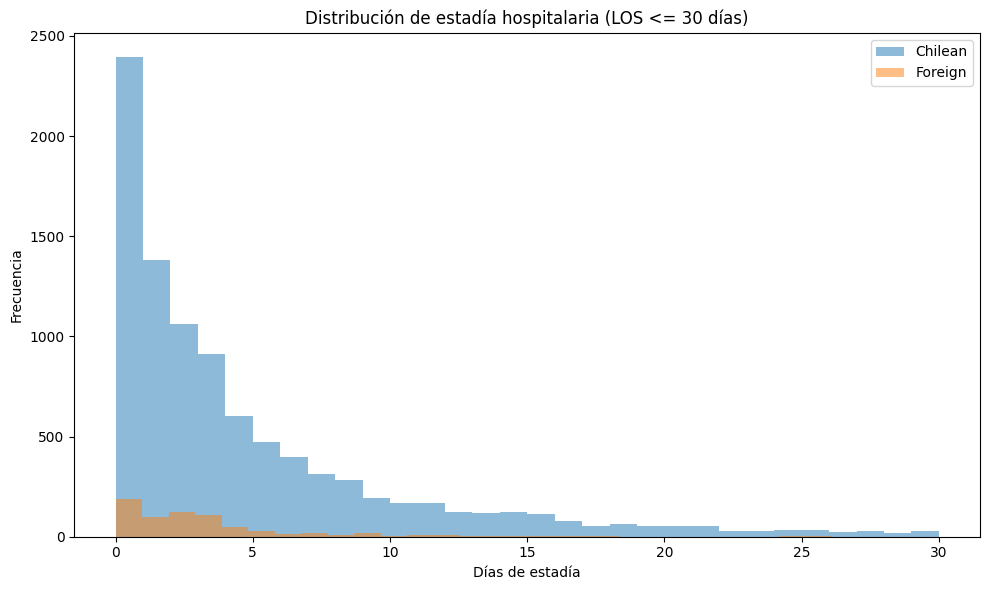

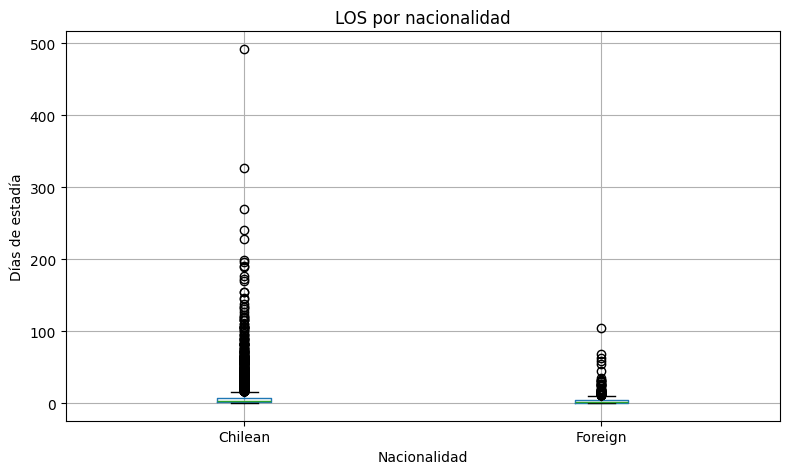


PARTE 2.2: SEVERIDAD (ABSOLUTA)
nat_group    Chilean  Foreign
sev_label                    
No severity     3421      286
Minor           4675      432
Moderate        3432      306
Major           3187      133


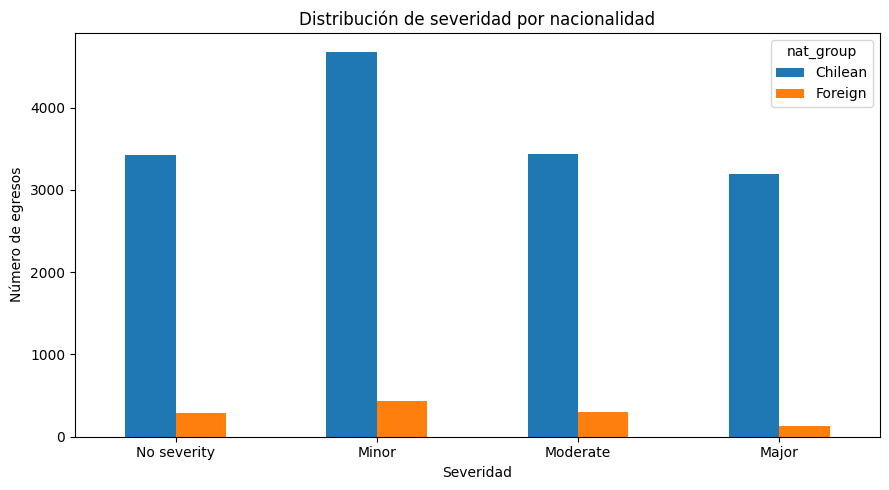


Distribución porcentual de severidad por nacionalidad:
nat_group    Chilean  Foreign
sev_label                    
No severity    23.25    24.72
Minor          31.77    37.34
Moderate       23.32    26.45
Major          21.66    11.50


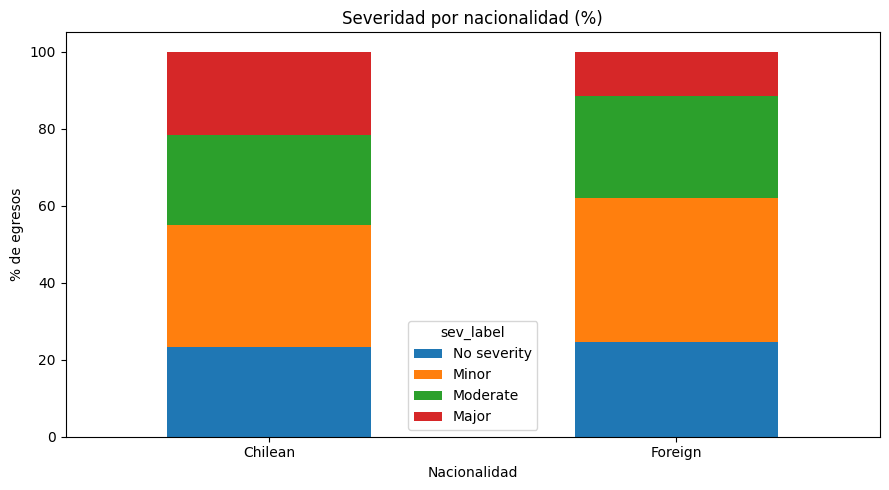


PARTE 2.3: TIPO DE ALTA
TIPOALTA_clean
DOMICILIO                                        14534
FALLECIDO                                          465
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO              340
HOSPITALIZACIÓN DOMICILIARIA                       207
ALTA VOLUNTARIA                                    169
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL         54
DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE        49
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS       23
DERIVACIÓN INST. PRIVADA (VOLUNTARIO)               22
FUGA DEL PACIENTE                                    9
Name: count, dtype: int64


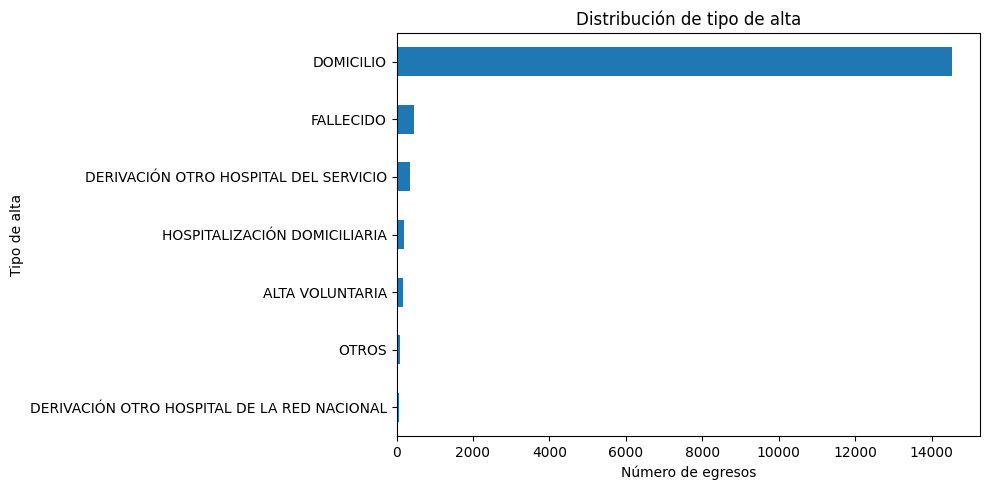


Mortalidad intrahospitalaria por nacionalidad:
  nat_group  mortality_rate
0   Chilean        3.058104
1   Foreign        1.296456


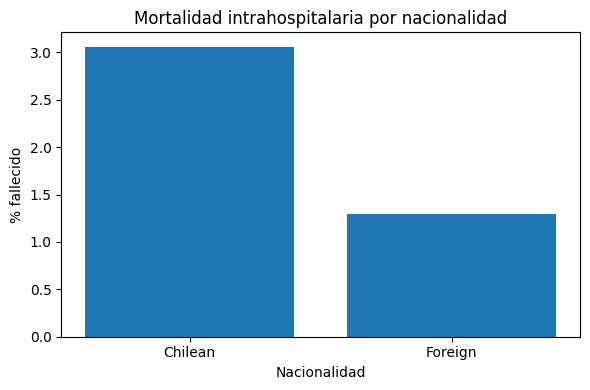

In [ ]:
# ============================================================
# PARTE 2: ESTADÍA, SEVERIDAD Y MORTALIDAD
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 2.1 LONGITUD DE ESTADÍA POR NACIONALIDAD
# ------------------------------------------------------------
los_tabla = (
    grd_com.groupby("nat_group")["los"]
    .agg(["mean", "median", "min", "max"])
    .reset_index()
)

print("\n" + "=" * 60)
print("PARTE 2.1: LOS POR NACIONALIDAD")
print(los_tabla)

# Para el histograma se acotan a 30 días para evitar que casos extremos
# distorsionen la lectura visual.
grd_los_plot = grd_com[
    grd_com["los"].notna() & (grd_com["los"] <= 30)
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

for grupo in ["Chilean", "Foreign"]:
    subset = grd_los_plot.loc[grd_los_plot["nat_group"] == grupo, "los"]
    if not subset.empty:
        ax.hist(subset, bins=30, alpha=0.5, label=grupo)

ax.set_title("Distribución de estadía hospitalaria (LOS <= 30 días)")
ax.set_xlabel("Días de estadía")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

# El boxplot complementa el histograma porque permite comparar dispersión,
# mediana y posibles valores atípicos entre grupos.
fig, ax = plt.subplots(figsize=(8, 5))

grd_com.boxplot(column="los", by="nat_group", ax=ax)

ax.set_title("LOS por nacionalidad")
ax.set_xlabel("Nacionalidad")
ax.set_ylabel("Días de estadía")
plt.suptitle("")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2.2 DISTRIBUCIÓN DE SEVERIDAD
# ------------------------------------------------------------
mapa_severidad = {
    0: "No severity",
    1: "Minor",
    2: "Moderate",
    3: "Major"
}

grd_com["IR_29301_SEVERIDAD_num"] = pd.to_numeric(
    grd_com["IR_29301_SEVERIDAD"],
    errors="coerce"
)

grd_com["sev_label"] = grd_com["IR_29301_SEVERIDAD_num"].map(mapa_severidad)

sev_tabla = (
    grd_com.groupby(["sev_label", "nat_group"])
    .size()
    .reset_index(name="cantidad")
)

sev_pivot = (
    sev_tabla.pivot(
        index="sev_label",
        columns="nat_group",
        values="cantidad"
    )
    .fillna(0)
)

orden_sev = ["No severity", "Minor", "Moderate", "Major"]
sev_pivot = sev_pivot.reindex(orden_sev).fillna(0)

print("\n" + "=" * 60)
print("PARTE 2.2: SEVERIDAD (ABSOLUTA)")
print(sev_pivot)

fig, ax = plt.subplots(figsize=(9, 5))

sev_pivot.plot(kind="bar", ax=ax)

ax.set_title("Distribución de severidad por nacionalidad")
ax.set_xlabel("Severidad")
ax.set_ylabel("Número de egresos")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# Aquí el porcentaje se calcula dentro de cada nacionalidad para comparar
# composición relativa y no solo volumen absoluto.
sev_pct = sev_pivot.div(sev_pivot.sum(axis=0), axis=1) * 100
sev_pct = sev_pct.fillna(0)

print("\nDistribución porcentual de severidad por nacionalidad:")
print(sev_pct.round(2))

fig, ax = plt.subplots(figsize=(9, 5))

sev_pct.T.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Severidad por nacionalidad (%)")
ax.set_xlabel("Nacionalidad")
ax.set_ylabel("% de egresos")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2.3 TIPO DE ALTA Y MORTALIDAD INTRAHOSPITALARIA
# ------------------------------------------------------------
grd_com["TIPOALTA_clean"] = (
    grd_com["TIPOALTA"]
    .astype(str)
    .str.strip()
    .str.upper()
)

tipoalta_tabla = grd_com["TIPOALTA_clean"].value_counts()

print("\n" + "=" * 60)
print("PARTE 2.3: TIPO DE ALTA")
print(tipoalta_tabla)

# Se muestran las categorías más frecuentes y el resto se agrupa en 'OTROS'
# para que el gráfico no quede demasiado fragmentado.
top_tipoalta = tipoalta_tabla.head(6).copy()
otros = tipoalta_tabla.iloc[6:].sum()

if otros > 0:
    top_tipoalta.loc["OTROS"] = otros

fig, ax = plt.subplots(figsize=(10, 5))

top_tipoalta.sort_values().plot(kind="barh", ax=ax)

ax.set_title("Distribución de tipo de alta")
ax.set_xlabel("Número de egresos")
ax.set_ylabel("Tipo de alta")
plt.tight_layout()
plt.show()

mort_tabla = (
    grd_com.groupby("nat_group")["TIPOALTA_clean"]
    .apply(lambda x: (x == "FALLECIDO").mean() * 100)
    .reset_index(name="mortality_rate")
)

print("\nMortalidad intrahospitalaria por nacionalidad:")
print(mort_tabla)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(mort_tabla["nat_group"], mort_tabla["mortality_rate"])

ax.set_title("Mortalidad intrahospitalaria por nacionalidad")
ax.set_xlabel("Nacionalidad")
ax.set_ylabel("% fallecido")
plt.tight_layout()
plt.show()

Una mayor longitud de estadía promedio en extranjeros podría indicar mayor severidad al ingreso o menor acceso a atención preventiva. La distribución de severidad permite identificar si los pacientes extranjeros llegan con condiciones más avanzadas. La mortalidad intrahospitalaria debe interpretarse con cautela: diferencias pequeñas pueden no ser estadísticamente significativas dado el tamaño muestral.

---
### Parte 3 — Análisis espacial: tasa de hospitalización

Se calcula la **tasa de hospitalización por 10.000 habitantes** para cada comuna, dividiendo el total de egresos por la población del Censo 2024 y multiplicando por 10.000. Esta tasa permite comparar el uso hospitalario entre Las Condes y Curacaví de forma equitativa, controlando las diferencias de tamaño poblacional.

> **Fórmula:** Tasa = (Egresos hospitalarios / Población) × 10.000

Se presenta tanto en mapa coroplético como en gráfico de barras.


PARTE 3.1: TASA DE HOSPITALIZACIÓN
   comuna nombre_comuna  discharges  poblacion  grd_rate_per_10k
0   13114    Las Condes       10656     296134        359.837101
1   13503      Curacaví        5216      35165       1483.293047


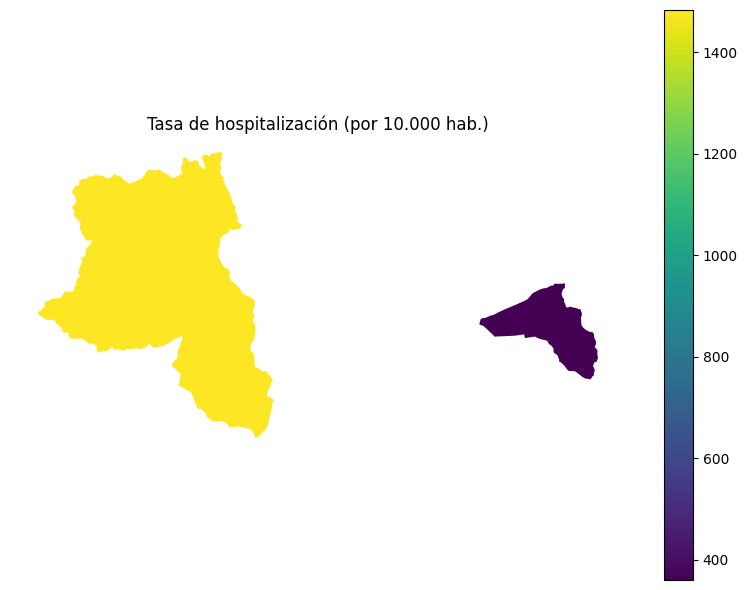

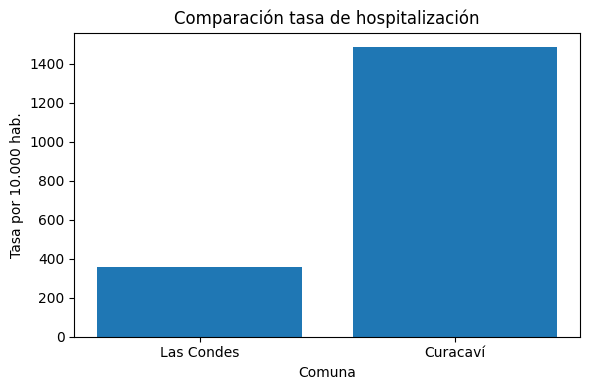


Tasa relativa de hospitalización:
  nombre_comuna  tasa_relativa
0    Las Condes       1.000000
1      Curacaví       4.122124


In [ ]:
# ============================================================
# PARTE 3: ANÁLISIS ESPACIAL
# ============================================================

# ------------------------------------------------------------
# 3.0 PREPARAR BASE DE TASAS
# ------------------------------------------------------------
RUTA_COMUNAS = os.path.join(RUTA_BASE, "COMUNAS")

MAPA_COMUNAS_COD = {
    "LAS CONDES": 13114,
    "CURACAVI": 13503
}

MAPA_COD_NOMBRE = {
    13114: "Las Condes",
    13503: "Curacaví"
}

if "COMUNA_CLEAN" not in grd_com.columns:
    grd_com["COMUNA_CLEAN"] = grd_com["COMUNA"].apply(limpiar_texto)

casos_grd = (
    grd_com["COMUNA_CLEAN"]
    .value_counts()
    .rename_axis("comuna_clean")
    .reset_index(name="discharges")
)

casos_grd["comuna"] = casos_grd["comuna_clean"].map(MAPA_COMUNAS_COD)
casos_grd["nombre_comuna"] = casos_grd["comuna"].map(MAPA_COD_NOMBRE)

persona_censo = pd.read_csv(
    os.path.join(RUTA_BASE, "personas_censo2024.csv"),
    sep=";",
    usecols=["comuna"]
)

persona_censo["comuna"] = pd.to_numeric(persona_censo["comuna"], errors="coerce")
persona_censo = persona_censo.dropna(subset=["comuna"]).copy()
persona_censo["comuna"] = persona_censo["comuna"].astype(int)

fer_poblacion = (
    persona_censo[persona_censo["comuna"].isin(MAPA_COD_NOMBRE.keys())]
    .groupby("comuna")
    .size()
    .reset_index(name="poblacion")
)

grd_tasa = (
    casos_grd
    .merge(fer_poblacion, on="comuna", how="left")
    .copy()
)

if grd_tasa["poblacion"].isna().any():
    raise ValueError("Hay comunas sin población asociada. Revisa personas_censo2024.csv.")

grd_tasa["grd_rate_per_10k"] = (
    grd_tasa["discharges"] / grd_tasa["poblacion"] * 10000
)

grd_tasa = grd_tasa[
    ["comuna", "nombre_comuna", "discharges", "poblacion", "grd_rate_per_10k"]
].sort_values("comuna").reset_index(drop=True)

# ------------------------------------------------------------
# 3.1 TASA DE HOSPITALIZACIÓN
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("PARTE 3.1: TASA DE HOSPITALIZACIÓN")
print(grd_tasa)

# -----------------------------
# MAPA
# -----------------------------
ruta_shape = os.path.join(RUTA_COMUNAS, "COMUNAS_v1.shp")
gdf = gpd.read_file(ruta_shape)

gdf["CUT_COM"] = pd.to_numeric(gdf["CUT_COM"], errors="coerce")
gdf = gdf.dropna(subset=["CUT_COM"]).copy()
gdf["CUT_COM"] = gdf["CUT_COM"].astype(int)

gdf_grd = gdf.merge(
    grd_tasa,
    left_on="CUT_COM",
    right_on="comuna",
    how="inner"
)

fig, ax = plt.subplots(figsize=(8, 6))

gdf_grd.plot(
    column="grd_rate_per_10k",
    legend=True,
    ax=ax
)

ax.set_title("Tasa de hospitalización (por 10.000 hab.)")
ax.axis("off")
plt.tight_layout()
plt.show()

# -----------------------------
# COMPARACIÓN ENTRE COMUNAS
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    grd_tasa["nombre_comuna"],
    grd_tasa["grd_rate_per_10k"]
)

ax.set_title("Comparación tasa de hospitalización")
ax.set_xlabel("Comuna")
ax.set_ylabel("Tasa por 10.000 hab.")
plt.tight_layout()
plt.show()

tasa_min = grd_tasa["grd_rate_per_10k"].min()

if pd.notna(tasa_min) and tasa_min > 0:
    grd_tasa["tasa_relativa"] = grd_tasa["grd_rate_per_10k"] / tasa_min
else:
    grd_tasa["tasa_relativa"] = np.nan

print("\nTasa relativa de hospitalización:")
print(grd_tasa[["nombre_comuna", "tasa_relativa"]])

*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .
*   .


Una mayor tasa de hospitalización no necesariamente indica peor salud poblacional — puede reflejar mayor acceso a servicios hospitalarios, mayor cobertura de seguros o mayor detección de enfermedades. La tasa relativa muestra cuántas veces más hospitalizaciones tiene una comuna respecto a la de menor tasa.

---
### Parte 4 — Tabla resumen comunal GRD

Se construye la tabla resumen comunal GRD con todos los indicadores calculados. Esta tabla se unirá con el resumen del Censo (Tarea 1) y del ENO para el análisis ecológico de la **Tarea 3**.

Indicadores incluidos:
- Total de egresos y desglose por nacionalidad
- Longitud de estadía promedio (total, chilenos y extranjeros)
- Severidad promedio
- Tasa de mortalidad intrahospitalaria
- Tasa de hospitalización por 10.000 habitantes
- Top 3 capítulos diagnósticos más frecuentes

In [ ]:
# ============================================================
# PARTE 4: TABLA RESUMEN FINAL
# ============================================================

# Si no existen aún, se definen los mapas de comuna.
MAPA_COMUNAS_COD = {
    "LAS CONDES": 13114,
    "CURACAVI": 13503
}

MAPA_COD_NOMBRE = {
    13114: "Las Condes",
    13503: "Curacaví"
}

RUTA_OUTPUT = os.path.join(RUTA_BASE, "output")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

# ------------------------------------------------------------
# 4.1 PREPARAR BASE COMUNAL
# ------------------------------------------------------------
if "COMUNA_CLEAN" not in grd_com.columns:
    grd_com["COMUNA_CLEAN"] = grd_com["COMUNA"].apply(limpiar_texto)

grd_base = grd_com.copy()
grd_base["codigo_comuna"] = grd_base["COMUNA_CLEAN"].map(MAPA_COMUNAS_COD)
grd_base["nombre_comuna"] = grd_base["codigo_comuna"].map(MAPA_COD_NOMBRE)

grd_base = grd_base.dropna(subset=["codigo_comuna"]).copy()
grd_base["codigo_comuna"] = grd_base["codigo_comuna"].astype(int)

# ------------------------------------------------------------
# 4.2 TOTAL EGRESOS Y COMPOSICIÓN POR NACIONALIDAD
# ------------------------------------------------------------
grd_total = (
    grd_base.groupby("codigo_comuna")
    .size()
    .reset_index(name="total_egresos")
)

grd_chilenos = (
    grd_base[grd_base["nat_group"] == "Chilean"]
    .groupby("codigo_comuna")
    .size()
    .reset_index(name="egresos_chilenos")
)

grd_extranjeros = (
    grd_base[grd_base["nat_group"] == "Foreign"]
    .groupby("codigo_comuna")
    .size()
    .reset_index(name="egresos_extranjeros")
)

# ------------------------------------------------------------
# 4.3 LOS PROMEDIOS TOTALES POR NACIONALIDAD
# ------------------------------------------------------------
grd_los_total = (
    grd_base.groupby("codigo_comuna")["los"]
    .mean()
    .reset_index(name="los_promedio")
)

grd_los_chilenos = (
    grd_base[grd_base["nat_group"] == "Chilean"]
    .groupby("codigo_comuna")["los"]
    .mean()
    .reset_index(name="los_chilenos")
)

grd_los_extranjeros = (
    grd_base[grd_base["nat_group"] == "Foreign"]
    .groupby("codigo_comuna")["los"]
    .mean()
    .reset_index(name="los_extranjeros")
)

# ------------------------------------------------------------
# 4.4 SEVERIDAD PROMEDIO
# ------------------------------------------------------------
if "IR_29301_SEVERIDAD_num" not in grd_base.columns:
    grd_base["IR_29301_SEVERIDAD_num"] = pd.to_numeric(
        grd_base["IR_29301_SEVERIDAD"],
        errors="coerce"
    )

grd_severidad = (
    grd_base.groupby("codigo_comuna")["IR_29301_SEVERIDAD_num"]
    .mean()
    .reset_index(name="severidad_promedio")
)

# ------------------------------------------------------------
# 4.5 MORTALIDAD INTRAHOSPITALARIA
# ------------------------------------------------------------
if "TIPOALTA_clean" not in grd_base.columns:
    grd_base["TIPOALTA_clean"] = (
        grd_base["TIPOALTA"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

grd_mortalidad = (
    grd_base.groupby("codigo_comuna")["TIPOALTA_clean"]
    .apply(lambda x: (x == "FALLECIDO").mean() * 100)
    .reset_index(name="mortalidad_pct")
)

# ------------------------------------------------------------
# 4.6 TOP 3 CAPÍTULOS POR COMUNA
# ------------------------------------------------------------
grd_top3 = (
    grd_base.assign(CAPITULO=grd_base["CAPITULO"].fillna("Sin clasificar"))
    .groupby("codigo_comuna")["CAPITULO"]
    .apply(lambda x: " | ".join(x.value_counts().head(3).index.tolist()))
    .reset_index(name="grd_top3_chapters")
)

# ------------------------------------------------------------
# 4.7 TASA DE HOSPITALIZACIÓN
# ------------------------------------------------------------
if "grd_tasa" not in globals():
    persona_censo = pd.read_csv(
        os.path.join(RUTA_BASE, "personas_censo2024.csv"),
        sep=";",
        usecols=["comuna"]
    )

    persona_censo["comuna"] = pd.to_numeric(persona_censo["comuna"], errors="coerce")
    persona_censo = persona_censo.dropna(subset=["comuna"]).copy()
    persona_censo["comuna"] = persona_censo["comuna"].astype(int)

    fer_poblacion = (
        persona_censo[persona_censo["comuna"].isin(MAPA_COD_NOMBRE.keys())]
        .groupby("comuna")
        .size()
        .reset_index(name="poblacion")
    )

    grd_tasa = (
        grd_total.rename(columns={"codigo_comuna": "comuna", "total_egresos": "discharges"})
        .merge(fer_poblacion, on="comuna", how="left")
    )

    grd_tasa["nombre_comuna"] = grd_tasa["comuna"].map(MAPA_COD_NOMBRE)
    grd_tasa["grd_rate_per_10k"] = (
        grd_tasa["discharges"] / grd_tasa["poblacion"] * 10000
    )

tasa_hosp = grd_tasa.rename(columns={
    "comuna": "codigo_comuna",
    "grd_rate_per_10k": "tasa_hosp_10k"
})[["codigo_comuna", "tasa_hosp_10k"]].copy()

tasa_hosp["codigo_comuna"] = pd.to_numeric(tasa_hosp["codigo_comuna"], errors="coerce")
tasa_hosp = tasa_hosp.dropna(subset=["codigo_comuna"]).copy()
tasa_hosp["codigo_comuna"] = tasa_hosp["codigo_comuna"].astype(int)

# ------------------------------------------------------------
# 4.8 UNIR TODO EN UNA SOLA TABLA
# ------------------------------------------------------------
grd_summary = (
    grd_total
    .merge(grd_chilenos, on="codigo_comuna", how="left")
    .merge(grd_extranjeros, on="codigo_comuna", how="left")
    .merge(grd_los_total, on="codigo_comuna", how="left")
    .merge(grd_los_chilenos, on="codigo_comuna", how="left")
    .merge(grd_los_extranjeros, on="codigo_comuna", how="left")
    .merge(grd_severidad, on="codigo_comuna", how="left")
    .merge(grd_mortalidad, on="codigo_comuna", how="left")
    .merge(tasa_hosp, on="codigo_comuna", how="left")
    .merge(grd_top3, on="codigo_comuna", how="left")
)

grd_summary["egresos_chilenos"] = grd_summary["egresos_chilenos"].fillna(0).astype(int)
grd_summary["egresos_extranjeros"] = grd_summary["egresos_extranjeros"].fillna(0).astype(int)
grd_summary["pct_extranjeros"] = (
    grd_summary["egresos_extranjeros"] / grd_summary["total_egresos"] * 100
)
grd_summary["nombre_comuna"] = grd_summary["codigo_comuna"].map(MAPA_COD_NOMBRE)

# ------------------------------------------------------------
# 4.9 ORDENAR, REDONDEAR Y MOSTRAR
# ------------------------------------------------------------
grd_summary = grd_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "total_egresos",
        "egresos_chilenos",
        "egresos_extranjeros",
        "pct_extranjeros",
        "los_promedio",
        "los_chilenos",
        "los_extranjeros",
        "severidad_promedio",
        "mortalidad_pct",
        "tasa_hosp_10k",
        "grd_top3_chapters"
    ]
].sort_values("codigo_comuna").reset_index(drop=True)

cols_round = [
    "pct_extranjeros",
    "los_promedio",
    "los_chilenos",
    "los_extranjeros",
    "severidad_promedio",
    "mortalidad_pct",
    "tasa_hosp_10k"
]

grd_summary[cols_round] = grd_summary[cols_round].round(2)

print("\n" + "=" * 60)
print("PARTE 4: TABLA RESUMEN GRD (FINAL)")
print(grd_summary)

# ------------------------------------------------------------
# 4.10 EXPORTAR Y CALCULAR TASA RELATIVA
# ------------------------------------------------------------
ruta_salida = os.path.join(RUTA_OUTPUT, "tarea2_grd_summary.csv")
grd_summary.to_csv(ruta_salida, index=False)

print(f"\nArchivo guardado en:\n{ruta_salida}")

tasa_min = grd_summary["tasa_hosp_10k"].min()

if pd.notna(tasa_min) and tasa_min > 0:
    grd_summary["tasa_relativa"] = (
        grd_summary["tasa_hosp_10k"] / tasa_min
    ).round(2)
else:
    grd_summary["tasa_relativa"] = np.nan


PARTE 4: TABLA RESUMEN GRD (FINAL)
   codigo_comuna nombre_comuna  total_egresos  egresos_chilenos  \
0          13114    Las Condes          10656              9651   
1          13503      Curacaví           5216              5064   

   egresos_extranjeros  pct_extranjeros  los_promedio  los_chilenos  \
0                 1005             9.43          5.92          6.13   
1                  152             2.91          6.49          6.54   

   los_extranjeros  severidad_promedio  mortalidad_pct  tasa_hosp_10k  \
0             3.79                1.43            2.93         359.84   
1             4.82                1.40            2.93        1483.29   

                                   grd_top3_chapters  
0  Cap.02  NEOPLASIAS (C00-D49) | Cap.19  LESIONE...  
1  Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...  

Archivo guardado en:
/content/drive/MyDrive/ColabNotebooks/output/tarea2_grd_summary.csv


La tabla resumen GRD queda guardada como `tarea2_grd_summary.csv`. Los indicadores de estadía, severidad y mortalidad permiten comparar el perfil de hospitalización entre Las Condes y Curacaví, y entre chilenos y extranjeros.

---
## Conclusiones

El análisis de los datasets ENO y GRD revela diferencias importantes en el panorama de salud de Las Condes y Curacaví:

**Respecto al ENO:**
- Las tasas de notificación permiten comparar equitativamente la carga de enfermedades de vigilancia epidemiológica entre comunas de distinto tamaño poblacional
- La presencia de categorías "Desconocido" en nacionalidad evidencia las limitaciones de los sistemas de registro administrativo en salud pública
- Las tendencias temporales revelan el impacto de eventos globales (pandemia COVID-19) sobre la notificación de enfermedades transmisibles

**Respecto al GRD:**
- Los capítulos diagnósticos más frecuentes reflejan el perfil epidemiológico típico de hospitales públicos chilenos
- Las diferencias en longitud de estadía y severidad entre chilenos y extranjeros deben interpretarse considerando que los hospitales públicos atienden principalmente a personas de menores recursos
- La tasa de hospitalización por 10.000 habitantes es el indicador más comparable entre comunas al controlar por diferencias de tamaño poblacional

Estos indicadores serán la base para el análisis de regresión ecológica de la **Tarea 3**, donde se explorarán correlaciones entre variables del Censo y los resultados de salud observados en ENO y GRD.



*   .
*   .
*   .
*   .*   .

*   .*   .

*   .*   .

*   .*   .

*   .*   .

*   .*   .

*   .*   .

*   .*   .

*   .*   .
*   .*   .

*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
*   .*   .
